# EDA — Project 1 (BRFSS / MICHD)

Goal: understand `x_train` / `y_train` **before** fitting `least_squares` or logistic.

**Rules:** NumPy + matplotlib/seaborn. **No pandas, no sklearn.**

This notebook lives in `doc/`. Data is `../data/`. Helpers are `../helpers.py`.

**How to run:** kernel = `ml`. Run top to bottom **once**. The first load of the CSVs is slow; later opens use `../data/cache_eda.npz` (gitignored).

**Done when** the last section prints three lists: `drop_cols`, `sentinel_codes`, `keep_for_baseline`, plus 5–10 bullets you can paste into the report.


## 0. Imports and paths


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns

    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

DOC = Path(".").resolve()
ROOT = DOC.parent if DOC.name == "doc" else DOC
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT))
from helpers import load_csv_data

print("ROOT", ROOT)
print("DATA", DATA, "exists", DATA.exists())


ROOT /Users/yijunliu/Documents/ML/ML_project_1
DATA /Users/yijunliu/Documents/ML/ML_project_1/data exists True


## 1. Load arrays (cache after the first time)

`load_csv_data` uses `np.genfromtxt` on ~328k × 321 cells. Save a `.npz` so you do not wait again.


In [2]:
CACHE = DATA / "cache_eda.npz"

if CACHE.exists():
    z = np.load(CACHE)
    y, x, ids_tr = z["y"], z["x"], z["ids_tr"]
    x_te, ids_te = z["x_te"], z["ids_te"]
    print("loaded cache", CACHE)
else:
    y, x, ids_tr, x_te, ids_te = load_csv_data(str(DATA))
    np.savez(CACHE, y=y, x=x, ids_tr=ids_tr, x_te=x_te, ids_te=ids_te)
    print("saved cache", CACHE)

with open(DATA / "x_train.csv") as f:
    names = np.array(f.readline().strip().split(",")[1:])

assert names.shape[0] == x.shape[1], (names.shape, x.shape)
print("y", y.shape, "x", x.shape, "x_te", x_te.shape)
print("n features", len(names))


saved cache /Users/yijunliu/Documents/ML/ML_project_1/data/cache_eda.npz
y (328135,) x (328135, 321) x_te (109379, 321)
n features 321


In [3]:
def col(name):
    hits = np.where(names == name)[0]
    if hits.size == 0:
        raise KeyError(name)
    return int(hits[0])


def rate_pos(mask):
    mask = np.asarray(mask)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(y[mask] == 1))


## 2. Class balance

CVD (`y = +1`) is rare. **Do not** use accuracy as the main score.


In [4]:
vals, counts = np.unique(y, return_counts=True)
print("labels", dict(zip(vals.tolist(), counts.tolist())))
n = y.size
n_pos = int(np.sum(y == 1))
n_neg = int(np.sum(y == -1))
print(f"+1 (disease)  {n_pos:7d}  {n_pos / n:.4f}")
print(f"-1 (healthy)  {n_neg:7d}  {n_neg / n:.4f}")
print("always-predict -1 accuracy would be", n_neg / n)


labels {-1: 299160, 1: 28975}
+1 (disease)    28975  0.0883
-1 (healthy)   299160  0.9117
always-predict -1 accuracy would be 0.911697929205967


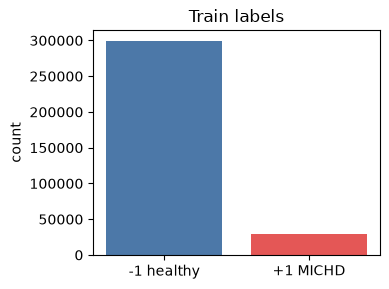

In [5]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["-1 healthy", "+1 MICHD"], [n_neg, n_pos], color=["#4c78a8", "#e45756"])
ax.set_ylabel("count")
ax.set_title("Train labels")
plt.tight_layout()
plt.show()


## 3. Missingness (`nan` = empty CSV cell)


In [6]:
nan_frac = np.mean(np.isnan(x), axis=0)
nan_te = np.mean(np.isnan(x_te), axis=0)
order = np.argsort(-nan_frac)

print(f"overall nan fraction train {nan_frac.mean():.4f}  test {nan_te.mean():.4f}")
print("columns 100% nan:", names[nan_frac == 1.0].tolist())
print("columns >90% nan:", int(np.sum(nan_frac > 0.90)))
print("columns >50% nan:", int(np.sum(nan_frac > 0.50)))
print("columns 0% nan:", int(np.sum(nan_frac == 0)))
print("\nworst 25 columns:")
for j in order[:25]:
    print(f"  {names[j]:16s}  train={nan_frac[j]:.3f}  test={nan_te[j]:.3f}")


overall nan fraction train 0.4479  test 0.4479
columns 100% nan: []
columns >90% nan: 99
columns >50% nan: 147
columns 0% nan: 82

worst 25 columns:
  LADULT            train=1.000  test=1.000
  COLGHOUS          train=1.000  test=1.000
  PCDMDECN          train=0.999  test=0.999
  ASERVIST          train=0.999  test=0.999
  ASDRVIST          train=0.999  test=0.999
  ASNOSLEP          train=0.999  test=0.999
  ASINHALR          train=0.999  test=0.999
  ASTHMED3          train=0.999  test=0.999
  ASYMPTOM          train=0.999  test=0.999
  ASACTLIM          train=0.999  test=0.999
  ASRCHKUP          train=0.999  test=0.999
  ASATTACK          train=0.999  test=0.999
  STREHAB1          train=0.998  test=0.999
  PCPSADE1          train=0.998  test=0.998
  HAREHAB1          train=0.998  test=0.998
  ASTHMAGE          train=0.998  test=0.998
  VINOCRE2          train=0.998  test=0.998
  CCLGHOUS          train=0.998  test=0.998
  HPVADSHT          train=0.997  test=0.997
  VIEYEXM2     

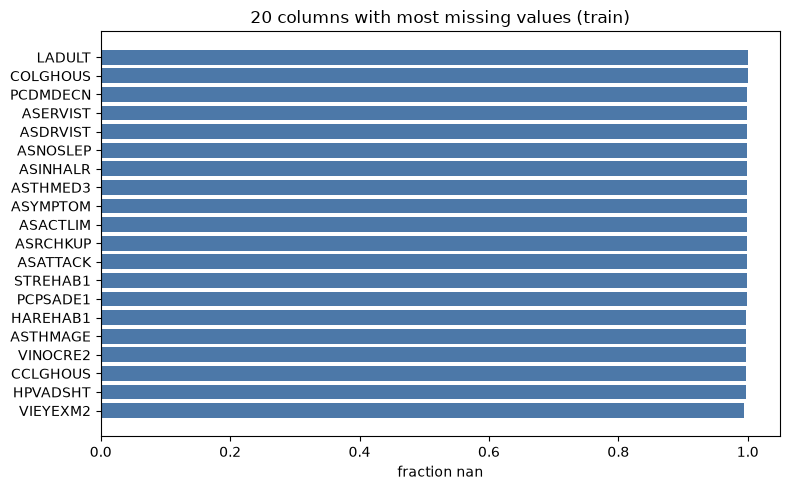

In [7]:
k = 20
fig, ax = plt.subplots(figsize=(8, 5))
idx = order[:k]
ax.barh(names[idx][::-1], nan_frac[idx][::-1], color="#4c78a8")
ax.set_xlabel("fraction nan")
ax.set_title("20 columns with most missing values (train)")
plt.tight_layout()
plt.show()


## 4. Sentinel codes (don’t know / refused / not asked)

BRFSS often stores **7, 9, 77, 88, 99, 777, 999, …** as *codes*, not as real amounts.
Treat frequent sentinels as missing later (not as the number 99).


In [8]:
SENTINEL_CODES = np.array(
    [7, 9, 77, 88, 99, 777, 999, 7777, 9999], dtype=float
)

sentinel_frac = np.zeros(len(names))
for j in range(len(names)):
    v = x[:, j]
    v = v[~np.isnan(v)]
    if v.size == 0:
        sentinel_frac[j] = np.nan
        continue
    sentinel_frac[j] = np.mean(np.isin(v, SENTINEL_CODES))

s_order = np.argsort(-np.nan_to_num(sentinel_frac, nan=-1))
print("columns with sentinel fraction > 5% (among observed values):")
n_hit = 0
for j in s_order:
    if np.isnan(sentinel_frac[j]) or sentinel_frac[j] <= 0.05:
        continue
    n_hit += 1
    print(f"  {names[j]:16s}  {sentinel_frac[j]:.3f}")
print("count", n_hit)


columns with sentinel fraction > 5% (among observed values):
  ADMOVE            0.901
  ADTHINK           0.866
  ADFAIL            0.841
  _CHISPNC          0.806
  ADDOWN            0.765
  DRNK3GE5          0.763
  CHILDREN          0.742
  ADPLEASR          0.730
  MENTHLTH          0.713
  ADEAT1            0.682
  LASTSMK2          0.671
  PHYSHLTH          0.663
  ASERVIST          0.658
  POORHLTH          0.597
  ADSLEEP           0.574
  ASDRVIST          0.570
  ADENERGY          0.441
  ASRCHKUP          0.378
  _DUALUSE          0.375
  _HCVU651          0.359
  EXRACT21          0.357
  EMPLOY1           0.308
  INCOME2           0.306
  HPVTEST           0.286
  VINOCRE2          0.273
  FEETCHK           0.254
  _AGEG5YR          0.204
  _INCOMG           0.179
  PAFREQ1_          0.177
  FMONTH            0.169
  HPVADSHT          0.160
  IMONTH            0.154
  _PNEUMO2          0.147
  DOCTDIAB          0.137
  JOINPAIN          0.135
  _PAREC1           0.130
  _

## 5. Constants / empty columns


In [ ]:
constant_cols = []
empty_cols = []
nunique = np.zeros(len(names), dtype=int)
for j, name in enumerate(names):
    v = x[:, j]
    v = v[~np.isnan(v)]
    if v.size == 0:
        empty_cols.append(name)
        nunique[j] = 0
        continue
    nunique[j] = np.unique(v).size
    if nunique[j] <= 1:
        constant_cols.append(name)

print("empty (all nan)", empty_cols)
print("constant (1 distinct value)", constant_cols)
print("nunique==2 (often yes/no)", int(np.sum(nunique == 2)))
print("nunique>=20 (more continuous-like)", int(np.sum(nunique >= 20)))


## 6. Survey metadata / IDs / weights — drop for modeling

These describe **how the person was sampled**, not their health.


In [ ]:
METADATA = [
    "_STATE",
    "FMONTH",
    "IDATE",
    "IMONTH",
    "IDAY",
    "IYEAR",
    "DISPCODE",
    "SEQNO",
    "_PSU",
    "CTELENUM",
    "PVTRESD1",
    "COLGHOUS",
    "STATERES",
    "CELLFON3",
    "LADULT",
    "NUMADULT",
    "NUMMEN",
    "NUMWOMEN",
    "CTELNUM1",
    "CELLFON2",
    "CADULT",
    "PVTRESD2",
    "CCLGHOUS",
    "CSTATE",
    "LANDLINE",
    "HHADULT",
    "QSTVER",
    "QSTLANG",
    "MSCODE",
    "_STSTR",
    "_STRWT",
    "_RAWRAKE",
    "_WT2RAKE",
    "_CHISPNC",
    "_CRACE1",
    "_CPRACE",
    "_CLLCPWT",
    "_DUALUSE",
    "_DUALCOR",
    "_LLCPWT",
]

meta_present = [n for n in METADATA if n in names]
meta_missing = [n for n in METADATA if n not in names]
print("metadata present", len(meta_present))
print("listed but not in file", meta_missing)
for n in meta_present[:15]:
    j = col(n)
    print(f"  {n:16s}  nan={nan_frac[j]:.3f}  nunique={nunique[j]}")


## 7. Leakage — features that *are* the disease or its immediate care

`_MICHD` is built from heart-attack / CHD questions (`CVDINFR4`, `CVDCRHD4`).
Those two names should **not** appear in `x`. Rehab / heart-aspirin items are still leaks.


In [ ]:
print("label-definition columns in x?", [n for n in names if n in ("CVDINFR4", "CVDCRHD4", "_MICHD")])

LEAK_CANDIDATES = [
    "HAREHAB1",
    "STREHAB1",
    "CVDASPRN",
    "ASPUNSAF",
    "RLIVPAIN",
    "RDUCHART",
    "RDUCSTRK",
    "CVDSTRK3",
]

print(f"{'name':12s}  {'nan':>6}  {'nuniq':>5}  {'P(+1|obs)':>10}  {'P(+1|miss)':>11}")
for n in LEAK_CANDIDATES:
    if n not in names:
        print(n, "NOT IN FILE")
        continue
    j = col(n)
    obs = ~np.isnan(x[:, j])
    print(
        f"{n:12s}  {nan_frac[j]:6.3f}  {nunique[j]:5d}  {rate_pos(obs):10.4f}  {rate_pos(~obs):11.4f}"
    )
    v = x[:, j]
    for val in np.unique(v[~np.isnan(v)])[:12]:
        m = v == val
        print(f"    value={val:g}  n={m.sum():6d}  P(+1)={rate_pos(m):.4f}")


**Decision for baseline (edit if your numbers disagree):**

- **Drop:** `HAREHAB1`, `STREHAB1`, `CVDASPRN`, `ASPUNSAF`, `RLIVPAIN`, `RDUCHART` (treatment / rehab after heart disease).
- **Keep for now, document:** `CVDSTRK3`, `RDUCSTRK` (stroke is related but not the MICHD label). Revisit if they dominate the model.


## 8. Duplicates / recodes

Prefer **one** version of height-weight-BMI and one version of age.


In [ ]:
GROUPS = {
    "body": ["WEIGHT2", "HEIGHT3", "HTIN4", "HTM4", "WTKG3", "_BMI5", "_BMI5CAT", "_RFBMI5"],
    "age": ["_AGEG5YR", "_AGE65YR", "_AGE80", "_AGE_G"],
    "smoke": ["SMOKE100", "SMOKDAY2", "_SMOKER3", "_RFSMOK3"],
    "health": ["GENHLTH", "_RFHLTH"],
}

for g, cols_g in GROUPS.items():
    print("\n==", g)
    for n in cols_g:
        if n not in names:
            print(" ", n, "missing")
            continue
        j = col(n)
        print(f"  {n:12s}  nan={nan_frac[j]:.3f}  nunique={nunique[j]:4d}")


## 9. Simple associations with the label (not a model)


In [ ]:
# Age group vs disease rate
j = col("_AGEG5YR")
age = x[:, j]
print("_AGEG5YR codes vs P(y=+1)")
for val in np.unique(age[~np.isnan(age)]):
    m = age == val
    print(f"  {val:6g}  n={m.sum():6d}  P(+1)={rate_pos(m):.4f}")


In [ ]:
j = col("_SMOKER3")
sm = x[:, j]
print("_SMOKER3 vs P(y=+1)")
for val in np.unique(sm[~np.isnan(sm)]):
    m = sm == val
    print(f"  {val:6g}  n={m.sum():6d}  P(+1)={rate_pos(m):.4f}")


In [ ]:
j = col("_BMI5")
bmi = x[:, j] / 100.0  # BRFSS often stores BMI * 100
valid = ~np.isnan(x[:, j])
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(bmi[valid & (y == -1)], bins=40, density=True, alpha=0.5, label="y=-1")
ax.hist(bmi[valid & (y == 1)], bins=40, density=True, alpha=0.5, label="y=+1")
ax.set_xlabel("BMI (column _BMI5 / 100)")
ax.set_ylabel("density")
ax.legend()
ax.set_title("BMI by label")
plt.tight_layout()
plt.show()
print("nan _BMI5", nan_frac[j])


In [ ]:
j_age = col("_AGEG5YR")
codes = np.unique(x[:, j_age][~np.isnan(x[:, j_age])])
rates = [rate_pos(x[:, j_age] == c) for c in codes]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(codes.astype(int).astype(str), rates, color="#e45756")
ax.set_xlabel("_AGEG5YR")
ax.set_ylabel("P(y = +1)")
ax.set_title("MICHD rate by age group")
plt.tight_layout()
plt.show()


## 10. Train vs test sanity


In [ ]:
print("nan fraction |train-test| mean", np.mean(np.abs(nan_frac - nan_te)))
print("columns with |nan_train - nan_test| > 0.05:")
for j in np.where(np.abs(nan_frac - nan_te) > 0.05)[0]:
    print(f"  {names[j]:16s}  {nan_frac[j]:.3f} vs {nan_te[j]:.3f}")

print("\ncolumns 100% nan on test only:", names[(nan_te == 1) & (nan_frac < 1)].tolist())


## 11. Lists for the baseline (Phase 2)

Edit the drop list if a printout above changed your mind. `keep_for_baseline` = everything else with <90% missing.


In [ ]:
sentinel_codes = [7, 9, 77, 88, 99, 777, 999, 7777, 9999]

drop_cols = []
drop_cols += meta_present
drop_cols += empty_cols
drop_cols += constant_cols
drop_cols += [
    "HAREHAB1",
    "STREHAB1",
    "CVDASPRN",
    "ASPUNSAF",
    "RLIVPAIN",
    "RDUCHART",
]
# recodes: keep BMI and age group, drop raw height/weight twins
drop_cols += ["WEIGHT2", "HEIGHT3", "HTIN4", "HTM4", "WTKG3", "_BMI5CAT", "_RFBMI5"]
drop_cols += [n for n in names if nan_frac[col(n)] > 0.90]

# unique, still in file
drop_cols = [n for n in dict.fromkeys(drop_cols) if n in names]

keep_for_baseline = [n for n in names if n not in drop_cols]

print("n drop", len(drop_cols))
print("n keep", len(keep_for_baseline))
print("sentinel_codes", sentinel_codes)
print("\n--- drop_cols ---")
print(drop_cols)
print("\n--- keep_for_baseline (first 40) ---")
print(keep_for_baseline[:40], "...")


## 12. Report bullets

See **§13** at the bottom (filled from the actual arrays). Do not copy the placeholder list from an un-run notebook.


## 13. Findings → what `preprocess.py` must do

Numbers below come from this notebook (and the same cache for sections you may not have re-run). **Copy the code cell after this into `preprocess.py` and implement the steps in order.**

### Problems in the raw data

| Finding | Number | Why it matters |
|---|---|---|
| Imbalanced labels | `+1` = 28 975 (**8.83%**), `−1` = 299 160 | Accuracy ≈ 91% if you always predict healthy. Do **not** drop the `+1` rows. Handle imbalance later (class weights / threshold), not by deleting data. |
| Lots of empty cells | **44.8%** `nan` train **and** test | Median-impute after drops. Fit medians on **train only**. |
| Rare modules | **99** columns with **>90%** `nan`; **147** with >50%; only **82** fully observed | Drop >90% missing for the baseline (too little signal, mostly “module not asked”). |
| Almost-empty admin | `LADULT`, `COLGHOUS` ≈ 100% `nan` | Drop (also in metadata). |
| Constants | `CTELENUM`, `COLGHOUS`, `STATERES`, `CTELNUM1`, `CELLFON2`, `CCLGHOUS` | Drop (no variance). |
| Survey ID / weights | 40 metadata fields (`SEQNO`, `_LLCPWT`, `_STATE`, dates, phone flags, …) | **Not health.** Drop. Using weights as features leaks the sampling design. |
| Label leakage | `HAREHAB1`: if answered, **P(y=+1)=1.0**. `STREHAB1` answered ⇒ 36% vs 8.8% base. `RDUCHART=1` ⇒ 23% vs `2` ⇒ 6.6% | Drop rehab / “aspirin to prevent heart disease” items. They are *consequences* of CHD, not inputs. |
| Label formula | `CVDINFR4`, `CVDCRHD4`, `_MICHD` **not** in `x` | Good — no exact label copy. |
| Stroke | `CVDSTRK3=1` ⇒ **37%** MICHD vs `2` ⇒ **7.6%** | Related disease, not the label. **Keep** for baseline; document. `RDUCSTRK` is >90% missing → already dropped. |
| Recodes | height/weight vs `_BMI5` | Keep **`_BMI5` only** (already in BMI units: min 12, median 27, max 98 — **do not divide by 100**). Drop `WEIGHT2`, `HEIGHT3`, `HTIN4`, `HTM4`, `WTKG3`, `_BMI5CAT`, `_RFBMI5`. |
| Age | `_AGEG5YR` 1→13: P(+1) from **0.5% to 22%**. Code **14** = refused/DK (n=3943) | Keep `_AGEG5YR`. Code **7 and 9 are real age groups**, not sentinels. |
| Smoking | `_SMOKER3`: never(4)=6.2%, former(3)=13.5%, daily(1)=10.4%, 9=unknown | Keep. Code **9** → `nan`. |
| Train vs test | mean \|nan_train − nan_test\| = **0.0005**; no column differs by >5% | Same drop/impute maps. No extra test-only columns. |
| After this recipe | drop **143** columns, keep **178** | Baseline width ≈ 178 (+ intercept later if you add a 1-column). |

### Dangerous trap: do **not** replace 7 / 9 / 88 globally

The sentinel scan flagged 72 columns, but many “hits” are **real codes**:

- `_AGEG5YR`: 7 = ages 50–54, 9 = 60–64. Only **14** is missing.
- `GENHLTH`, `_SMOKER3`, yes/no items: 7/9 often mean DK/refused — those *should* become `nan`.
- `PHYSHLTH` / `MENTHLTH` / `POORHLTH` / `CHILDREN`: **88 = none (zero days / no children)**. 77/99 = DK/refused. If you map 88→`nan` you delete the healthiest answers.

### `preprocess.py` steps (implement in this order)

1. Read header of `x_train.csv` → `names` (skip `Id`). Align columns of `x` and `x_test` by **name**.
2. **Drop** every name in `DROP_COLS` (list in the next cell). Apply the same indices to train, val, and test.
3. **Sentinels → `nan` (column-wise):**
   - Default for kept columns: `{77, 99, 777, 999, 7777, 9999}` → `nan`.
   - Also `{7, 9}` → `nan` **except** on `_AGEG5YR`, `_AGE65YR`, `_AGE80`, `_AGE_G`, and any column whose valid codebook uses 7 or 9 as a real level (when unsure, do **not** wipe 7/9 on `_AGE*` / `_BMI5`).
   - `_AGEG5YR`: only `14` → `nan`.
   - `PHYSHLTH`, `MENTHLTH`, `POORHLTH`, `CHILDREN`: `88` → `0`; `77` and `99` → `nan`.
4. **Impute:** for each kept column, `median` of **train** (ignore `nan`). Fill train/val/test with that vector. (Optional later: missing-indicator columns.)
5. **Standardize:** `(x - mean_train) / std_train` with `std` computed on imputed **train**; if `std==0` leave zeros. Apply same mean/std to val/test.
6. **Do not shuffle ids.** Return `ids` unchanged for submissions.
7. **Labels:** keep `y ∈ {+1,-1}` for least squares / ridge. For logistic, map `(y + 1) / 2` → `{0,1}` **after** preprocess, in `run.py`.
8. **No pandas.** Fit statistics on the training fold only (if you split inside preprocess, split **before** median/std).

Val split (suggested in `run.py`, not EDA): e.g. last 20% of shuffled train indices with a fixed seed — but compute medians on the 80% only.



In [ ]:
# Paste these constants into preprocess.py (baseline v1).
# Generated from EDA on cache_eda.npz.

SENTINEL_DEFAULT = (77, 99, 777, 999, 7777, 9999)
SENTINEL_DK_REFUSED = (7, 9)  # use only on columns where 7/9 are NOT real levels

AGE_MISSING = {14}  # _AGEG5YR
DAYS_NONE_TO_ZERO = ("PHYSHLTH", "MENTHLTH", "POORHLTH", "CHILDREN")  # 88 -> 0

DROP_COLS = [
    "_STATE", "FMONTH", "IDATE", "IMONTH", "IDAY", "IYEAR", "DISPCODE", "SEQNO", "_PSU",
    "CTELENUM", "PVTRESD1", "COLGHOUS", "STATERES", "CELLFON3", "LADULT", "NUMADULT",
    "NUMMEN", "NUMWOMEN", "CTELNUM1", "CELLFON2", "CADULT", "PVTRESD2", "CCLGHOUS",
    "CSTATE", "LANDLINE", "HHADULT", "QSTVER", "QSTLANG", "MSCODE", "_STSTR", "_STRWT",
    "_RAWRAKE", "_WT2RAKE", "_CHISPNC", "_CRACE1", "_CPRACE", "_CLLCPWT", "_DUALUSE",
    "_DUALCOR", "_LLCPWT",
    "HAREHAB1", "STREHAB1", "CVDASPRN", "ASPUNSAF", "RLIVPAIN", "RDUCHART",
    "WEIGHT2", "HEIGHT3", "HTIN4", "HTM4", "WTKG3", "_BMI5CAT", "_RFBMI5",
    "NUMPHON2", "INSULIN", "BLDSUGAR", "FEETCHK2", "DOCTDIAB", "CHKHEMO3", "FEETCHK",
    "EYEEXAM", "DIABEYE", "DIABEDU", "CRGVREL1", "CRGVLNG1", "CRGVHRS1", "CRGVPRB1",
    "CRGVPERS", "CRGVHOUS", "CRGVMST2", "VIDFCLT2", "VIREDIF3", "VIPRFVS2", "VINOCRE2",
    "VIEYEXM2", "VIINSUR2", "VICTRCT4", "VIGLUMA2", "VIMACDG2", "CDHOUSE", "CDASSIST",
    "CDHELP", "CDSOCIAL", "CDDISCUS", "WTCHSALT", "LONGWTCH", "DRADVISE", "ASTHMAGE",
    "ASATTACK", "ASERVIST", "ASDRVIST", "ASRCHKUP", "ASACTLIM", "ASYMPTOM", "ASNOSLEP",
    "ASTHMED3", "ASINHALR", "RDUCSTRK", "ARTTODAY", "ARTHWGT", "ARTHEXER", "ARTHEDU",
    "TETANUS", "HPVADVC2", "HPVADSHT", "SHINGLE2", "HADMAM", "HOWLONG", "HADPAP2",
    "LASTPAP2", "HPVTEST", "HPLSTTST", "HADHYST2", "PROFEXAM", "LENGEXAM", "LSTBLDS3",
    "HADSGCO1", "LASTSIG3", "PCPSAAD2", "PCPSADI1", "PCPSARE1", "PSATEST1", "PSATIME",
    "PCPSARS1", "PCPSADE1", "PCDMDECN", "SCNTPAID", "SCNTWRK1", "SCNTLPAD", "SCNTLWK1",
    "CASTHNO2", "EMTSUPRT", "LSATISFY", "ADPLEASR", "ADDOWN", "ADSLEEP", "ADENERGY",
    "ADEAT1", "ADFAIL", "ADTHINK", "ADMOVE", "MISTMNT", "ADANXEV",
]

# 178 names remain; keep CVDSTRK3, _AGEG5YR, _BMI5, _SMOKER3, GENHLTH, BPHIGH4, ...
NEVER_TREAT_7_9_AS_MISSING = (
    "_AGEG5YR", "_AGE65YR", "_AGE80", "_AGE_G", "_BMI5",
)

print("n DROP_COLS", len(DROP_COLS))

